Created by Justin Cooke 02/11/2026

The purpose of this script is to investigate the influence of spatial area on the common mode, with implications for variance.

Comparison of variance between HYCOM in the region of 22N to 28N and 83W to 90W vs in the CPIES region of 25 to 27.5N and 86W to 89W revealed the CPIES Variance to be 2.5x less than that in the HYCOM, despite having higher EKE.

In [ ]:
# Import modules

# Sci computing
import numpy as np
import scipy as sp
import seawater as sw
import scipy.sparse.linalg as sla
import scipy.io as spio
from contourpy import contour_generator
import pyfftw 

# Importing bathymetry (tiff)
import rasterio as geo

# Parallel comupting
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

# For Data
import netCDF4 as nc
import xarray as xr

# Plotting stuff
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grdspc
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
import cmocean as cm

# Gen stuff
from datetime import date
today = date.today()

In [ ]:
# Low Pass Filter

from scipy.signal import butter, filtfilt

def lowpassfilt(data, filtT, sampT):
    """
    Low-pass filter a 1D data vector using a second-order Butterworth filter.
    Filtering is applied forward and backward to eliminate phase shift.

    Parameters
    ----------
    data : array_like
        Input data vector (1D array). Can be row or column oriented.
    filtT : float
        Filter period (same units as sampT).
    sampT : float
        Sampling period (same units as filtT).

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape as input.
    """

    data = np.asarray(data)
    if data.ndim != 1:
        raise ValueError("Input must be a 1D vector, not an array.")

    # Check if input was a row vector (for shape preservation)
    was_row = data.ndim == 1 and data.shape[0] < data.shape[-1]

    # Remove linear trend between endpoints
    n = len(data)
    x = np.arange(1, n + 1)
    p = np.polyfit([1, n], [data[0], data[-1]], 1)
    lineartrend = np.polyval(p, x)
    detrended = data - lineartrend

    # Check for NaNs
    if np.isnan(detrended).any():
        raise ValueError("Data contains NaNs; remove them before filtering.")

    # Butterworth filter setup
    # Wn is the normalized cutoff frequency (Nyquist = 0.5 / sampT)
    Wn = (2.0 / filtT) * sampT
    if Wn >= 1:
        raise ValueError("Cutoff frequency too high; ensure filtT > 2 * sampT.")
    b, a = butter(2, Wn)

    # Zero-phase filtering
    filtered = filtfilt(b, a, detrended)

    # Add linear trend back
    out = filtered + lineartrend

    # Preserve input orientation
    if was_row:
        out = out.reshape(1, -1)
    else:
        out = out.reshape(-1)

    return out


# Band-pass filter

def butterfilt_bandpass(x, order, filtThi, filtTlo, sampT):
    """
    Band-pass Butterworth filter with zero-phase (forward–reverse) filtering.

    Parameters
    ----------
    x : array_like
        Input vector (row or column). Will be returned in the same orientation.
    order : int
        Order of the Butterworth filter.
    filtThi : float
        Longer period of the band (high cutoff).
    filtTlo : float
        Shorter period of the band (low cutoff).
    sampT : float
        Sampling period. Must have same units as filtThi/filtTlo.

    Returns
    -------
    out : ndarray
        Filtered data vector, same shape (row/column) as input.
    """

    x = np.asarray(x)

    # Ensure input is 1-D vector
    if x.ndim != 1 and not (x.ndim == 2 and 1 in x.shape):
        raise ValueError("Input must be a vector, not an array.")

    # Preserve original orientation
    transpose_back = False
    if x.ndim == 2:
        if x.shape[0] == 1:  # row vector
            x = x.flatten()
            transpose_back = True
        elif x.shape[1] == 1:  # column vector
            x = x.flatten()
        else:
            raise ValueError("Input must be a vector, not a matrix.")

    n = x.size

    # Trend removal (linear ramp)
    t = np.arange(1, n + 1)
    P = np.polyfit([1, n], [x[0], x[-1]], 1)
    linear_trend = np.polyval(P, t)
    x_detrended = x - linear_trend

    # Normalized band edges (MATLAB: Wnlo = (2/filtTlo)*sampT)
    Wnlo = (2.0 / filtTlo) * sampT  # upper normalized cutoff
    Wnhi = (2.0 / filtThi) * sampT  # lower normalized cutoff
    Wn = [Wnhi, Wnlo]

    # Create Butterworth filter
    b, a = butter(order, Wn, btype='bandpass')

    # NaN check
    if np.isnan(x_detrended).any():
        raise ValueError("NaNs present in input data. Remove them before filtering.")

    # Zero-phase filtering
    out = filtfilt(b, a, x_detrended)

    # MATLAB code *comments out* adding the trend back:
    # out = out + linear_trend
    # For direct equivalence, we keep it commented.
    
    # Reshape to original orientation
    if transpose_back:
        out = out[np.newaxis, :]

    return out


# Create a function that finds distance based on great circle distance -- output in km will convert to m

def dist_calc(lat1,lat2,lon1,lon2):

    RadEarth = 6371  # [km]

    # Convert points from degrees to radians
    phi_1 = np.deg2rad(lat1) 
    phi_2 = np.deg2rad(lat2)
    lam_1 = np.deg2rad(lon1)
    lam_2 = np.deg2rad(lon2)

    # take difference between lat and lon points
    delphi = phi_2 - phi_1
    dellam = lam_2 - lam_1

    # Calculate circle greatest distance
    thisDist = 2 * RadEarth * np.asin( np.sqrt(( 1 - np.cos((delphi)) +
                                    ((np.cos(phi_1)) * np.cos(phi_2) * 
                                    (1 - np.cos(dellam) ) )) / 2)) 
    
    # Convert from km to m
    thisDist = thisDist # * 1000
    
    return(thisDist)

In [ ]:
# For plotting; have the bathymetry of the gulf

ds_gulf = geo.open('/home/justin_cooke_uri_edu/DeepCyclones/gulf.tiff')
#ds_gulf = geo.open('../gulf.tiff')
img = ds_gulf.read(1)

(gm,gn) = np.shape(img)
gulf_lon = np.linspace(-90,-82,gn)
gulf_lat = np.linspace(22,28,gm)

# To get the aspect ratio right
ymid = np.mean(gulf_lat)
ymid_rad = ymid*np.pi/180

# For plotting: labels

lon_xticks = np.array((-90,-89,-88,-87,-86,-85,-84,-83))
lon_xticklbls = ['$90^\circ$W','$89^\circ$W','$88^\circ$W','$87^\circ$W','$86^\circ$W','$85^\circ$W','$84^\circ$W','$83^\circ$W']

lat_yticks = np.array((22,23,24,25,26,27,28))
lat_yticklbls = ['$22^\circ$N','$23^\circ$N','$24^\circ$N','$25^\circ$N','$26^\circ$N','$27^\circ$N','$28^\circ$N']

In [ ]:
ds_eref      = xr.open_mfdataset('./hycom_data/CommonMode/hycom_etaref_*.nc',combine='nested',concat_dim='MT')
ds_eref_noCM = xr.open_mfdataset('./hycom_data/hycom_etaref_*.nc',combine='nested',concat_dim='MT')
ds_ssh       = xr.load_dataset('./hycom_data/hycom_ssh_filtered.nc')
ds_u         = xr.load_dataset('./hycom_data/hycom_u.nc')
ds_v         = xr.load_dataset('./hycom_data/hycom_v.nc')

In [ ]:
# Load the variables we care about
eref_wCM = ds_eref['eta_ref_wCommonMode']
eref     = ds_eref_noCM['eta_ref']
ssh      = ds_ssh['ssh']
u        = ds_u['u']
u        = np.squeeze(u)
v        = ds_v['v']
v        = np.squeeze(v)

lon = ds_eref['Longitude']
lat = ds_eref['Latitude']

Nt,Nlat,Nlon = eref_wCM.shape

In [ ]:
# Create a smaller eref_wCM but in the cpies region only

# Create a bounding box
dsc_minlat = lat.values[81]
dsc_maxlat = lat.values[-15]

dsc_minlon = lon.values[25]
dsc_maxlon = lon.values[100]

print(f'Bounded by {dsc_minlat}N to {dsc_maxlat}N and {dsc_minlon}W to {dsc_maxlon}W')

# Select the values within the DSC bounding box and then avg them spatially
cpies_eref = eref_wCM.sel(Latitude=slice(dsc_minlat,dsc_maxlat),Longitude=slice(dsc_minlon,dsc_maxlon))
Nt_cpies,Nlat_cpies,Nlon_cpies = cpies_eref.shape

cpies_lon = lon.values[25:101]
cpies_lat = lat.values[81:-14]

In [ ]:
# Random two year instances
Nt_lim = Nt - 2*365 - 1

import random
my_start_idx = random.randint(0,Nt_lim)
my_end_idx = my_start_idx + 2*365

print(my_start_idx,my_end_idx)

eref_2yrs = eref_wCM[my_start_idx:my_end_idx,:,:]
cpies_2yrs = cpies_eref[my_start_idx:my_end_idx,:,:]

time_axis = np.linspace(0,Nt,Nt)
time_2yr_axis = time_axis[my_start_idx:my_end_idx]

eref_noCM = eref_2yrs - xr.DataArray.mean(eref_2yrs,dim=["Latitude","Longitude"],skipna=True)
cpies_eref_noCM = cpies_2yrs - xr.DataArray.mean(cpies_2yrs,dim=["Latitude","Longitude"],skipna=True)

full_eref_noCM = eref_wCM - xr.DataArray.mean(eref_wCM,dim=["Latitude","Longitude"],skipna=True)
full_cpies_eref_noCM = cpies_eref - xr.DataArray.mean(cpies_eref,dim=["Latitude","Longitude"],skipna=True)

full_big_CM = xr.DataArray.mean(eref_wCM,dim=["Latitude","Longitude"],skipna=True)
full_small_CM = xr.DataArray.mean(cpies_eref,dim=["Latitude","Longitude"],skipna=True)

big_CM = xr.DataArray.mean(eref_2yrs,dim=["Latitude","Longitude"],skipna=True)
small_CM = xr.DataArray.mean(cpies_2yrs,dim=["Latitude","Longitude"],skipna=True)

fig = plt.subplots(figsize=(20,5))

plt.plot(time_2yr_axis,small_CM,color='green',linestyle='-')
plt.plot(time_2yr_axis,big_CM,color='purple',linestyle='-')

In [ ]:
# Create the D Matrix

# Get eta ref values
eref_noCM_vals = eref_noCM.values
cpies_eref_noCM_vals = cpies_eref_noCM.values

Nt_now = eref_noCM_vals.shape[0]

# Create a mask containing all the points that are not NaNs
mask = ~np.isnan(eref_noCM_vals[0,:,:])
idx = np.where(mask)
mask_2 = ~np.isnan(cpies_eref_noCM_vals[0,:,:])
idx_2 = np.where(mask_2)

# Create D
D = eref_noCM_vals[:,idx[0],idx[1]]
D = np.moveaxis(D,0,1)
D_2 = cpies_eref_noCM_vals[:,idx_2[0],idx_2[1]]
D_2 = np.moveaxis(D_2,0,1)

bp_D = np.empty_like(D)
bp_D_2 = np.empty_like(D_2)

filtThi = 150.0
filtTlo = 60.0

fc = 10.0
sc = 1.0

for i in range(D.shape[0]):
    bp_D[i,:] = butterfilt_bandpass(D[i,:],2,filtThi,filtTlo,sc)
for i in range(D_2.shape[0]):
    bp_D_2[i,:] = butterfilt_bandpass(D_2[i,:],2,filtThi,filtTlo,sc)

eref_noCM_vals_bp = np.full((Nt_now,Nlat,Nlon),np.nan)
cpies_eref_noCM_vals_bp = np.full((Nt_now,Nlat_cpies,Nlon_cpies),np.nan)

for t in range(Nt_now):
    cpies_eref_noCM_vals_bp[t,idx_2[0],idx_2[1]] = bp_D_2[:,t]
    eref_noCM_vals_bp[t,idx[0],idx[1]] = bp_D[:,t]

cpies_eref_noCM_bp = xr.DataArray(
    cpies_eref_noCM_vals_bp,
    coords=cpies_eref_noCM.coords,
    dims=cpies_eref_noCM.dims,
    name='cpies_eref_noCM_bp'
)

eref_bp = xr.DataArray(
    eref_noCM_vals_bp,
    coords=eref_noCM.coords,
    dims=eref_noCM.dims,
    name='eref_noCM_bp'
)
# Plot mean and variance of everything

fig = plt.subplots(1,2,figsize=(16,8))

ax = plt.subplot(1,2,1)
#cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
cb = ax.contourf(lon,lat,np.nanvar(eref_noCM_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#ax.set_title('18-year Variance of $\eta_{ref}$',fontsize=18)
ax.set_title(f'{int(filtThi)}-{int(filtTlo)} Days',fontsize=18)

ax = plt.subplot(1,2,2)
#cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
cb = ax.contourf(cpies_lon,cpies_lat,np.nanvar(cpies_eref_noCM_vals_bp,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.0005,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#ax.set_title('18-year Variance of $\eta_{ref}$',fontsize=18)
ax.set_title(f'{int(filtThi)}-{int(filtTlo)} Days',fontsize=18)



#fig.savefig(f'./Figures/BP_{int(filtThi)}to{int(filtTlo)}_var_ampcolor_{today}.svg',format='svg')
#fig.savefig(f'./Figures/LP_{fc}_18yr_var_ampcolor_{today}.svg',format='svg')

In [113]:
# Now we want to calculate variance every two years for the cpies region to create a pdf

from scipy.stats import norm

# Want to get variance over 2 yeras 
two_yr_int = 365*2

# Allocate array
cpies_twoYr_meanvar = np.empty(17)
cpies_twoYr_var = np.empty((17,full_cpies_eref_noCM.values.shape[1],full_cpies_eref_noCM.values.shape[2]))

# Calculate mean variance in two year intervals over cpies region
for n in range(17):
    my_start = n*365
    my_end = my_start + two_yr_int
    #print(f'Start: {my_start}\nEnd: {my_end}')

    my_interval = full_cpies_eref_noCM.values[my_start:my_end,:,:]
    this_var = np.nanvar(my_interval,axis=0)
    
    this_mean_var = np.nanmean(this_var,axis=(0,1))
    cpies_twoYr_var[n,:,:] = this_var
    cpies_twoYr_meanvar[n] = this_mean_var
    #print(f'Mean Variance: {this_mean_var}')
    


/tmp/ipykernel_3339402/492900183.py:19: RuntimeWarning: Degrees of freedom <= 0 for slice.
  this_var = np.nanvar(my_interval,axis=0)


In [125]:
# Load the CPIES data


ds_oi_ugos = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')
#ds_oi = spio.loadmat('./ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')

oi_lat_ugos = ds_oi_ugos['OIprs']['lat'][0][0]
oi_lon_ugos = ds_oi_ugos['OIprs']['lon'][0][0]

# Let's grab that subset of data and then average to have 24 hour times 
oi_prs = ds_oi_ugos['OIprs']['prs'][0][0]

(nlat,nlon,nt) = oi_prs.shape

oi_prs_daily = np.zeros((nlat,nlon,nt))


countMe = 0
j = 0
while j < ((nt) - 1):
    firstHalf = oi_prs[:,:,j]
    secondHalf = oi_prs[:,:,j+1]

    avg_val = (firstHalf + secondHalf) / 2 
    oi_prs_daily[:,:,countMe] = avg_val
    
    countMe += 1
    
    j += 2

# output: [lat x lon x time]
oi_eref_daily_ugos = (oi_prs_daily*np.power(10,4))/(1040*9.81) # converts from pres to eta ref

oi_meanvar_ugos = np.mean(np.nanvar(oi_eref_daily_ugos,axis=2),axis=(0,1))

########## Do for Dynloop now

ds_oi_dyn = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/Dynloop_OImapBottomPrs_40d_70k_65k_15Vn.mat')
#ds_oi = spio.loadmat('./ObsData/OImapBottomPrs_20d_70k_65k_15Vn.mat')

oi_lat = ds_oi_dyn['OIprs']['lat'][0][0]
oi_lon = ds_oi_dyn['OIprs']['lon'][0][0]

# Let's grab that subset of data and then average to have 24 hour times 
oi_prs = ds_oi_dyn['OIprs']['prs'][0][0]

(nlat,nlon,nt) = oi_prs.shape

oi_prs_daily = np.zeros((nlat,nlon,nt))

countMe = 0
j = 0
while j < ((nt) - 1):
    firstHalf = oi_prs[:,:,j]
    secondHalf = oi_prs[:,:,j+1]

    avg_val = (firstHalf + secondHalf) / 2 
    oi_prs_daily[:,:,countMe] = avg_val
    
    countMe += 1
    
    j += 2

# output: [lat x lon x time]
oi_eref_daily_dyn = (oi_prs_daily*np.power(10,4))/(1040*9.81) # converts from pres to eta ref

oi_meanvar_dyn = np.mean(np.nanvar(oi_eref_daily_dyn,axis=2),axis=(0,1))

In [93]:
print(f'UGOS Mean Variance: {oi_meanvar_ugos}\nDynLoop Mean Variance: {oi_meanvar_dyn}')
cpies_twoYr_meanvar

UGOS Mean Variance: 0.00037471603480625546
DynLoop Mean Variance: 0.0005121046853509008


array([0.00121723, 0.00084918, 0.00079989, 0.00082431, 0.00082973,
       0.00045763, 0.00059917, 0.00094735, 0.00086339, 0.00052564,
       0.0004854 , 0.0007867 , 0.00089355, 0.0007217 , 0.00078206,
       0.00110814, 0.00072607])

<>:34: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3339402/144125713.py:34: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('HYCOM 2-Year Interval Mean Variance of $\eta_{ref}$', fontsize=14)


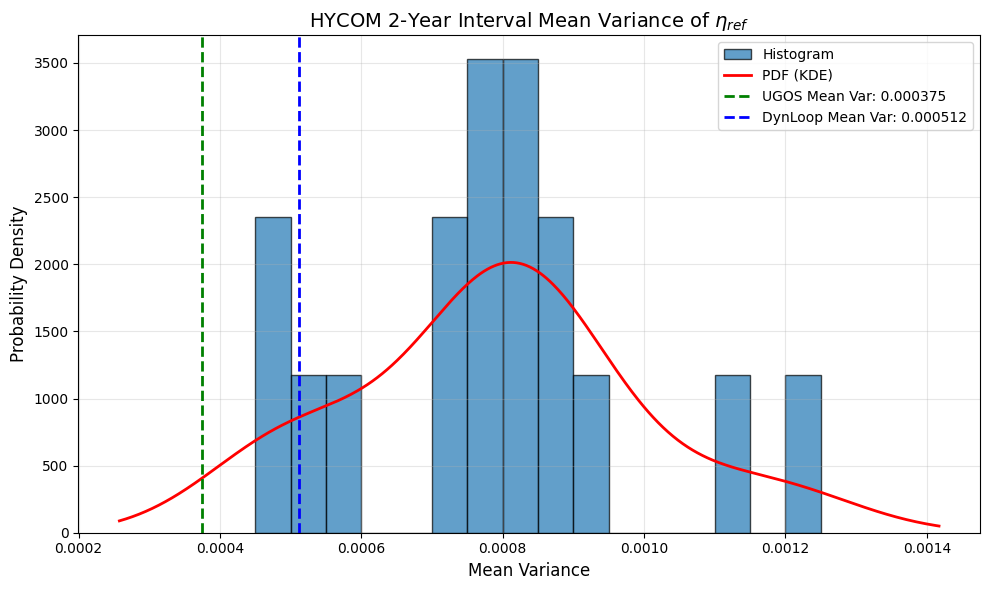

In [109]:
from scipy import stats

# Define bins with 0.00005 width
bin_width = 0.00005
bin_min = np.floor(cpies_twoYr_meanvar.min() / bin_width) * bin_width
bin_max = np.ceil(cpies_twoYr_meanvar.max() / bin_width) * bin_width
bins = np.arange(bin_min, bin_max + bin_width, bin_width)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram (normalized to density)
ax.hist(cpies_twoYr_meanvar, bins=bins, density=True, alpha=0.7, 
        edgecolor='black', label='Histogram')

# Fit KDE for PDF estimation
kde = stats.gaussian_kde(cpies_twoYr_meanvar)
x_range = np.linspace(cpies_twoYr_meanvar.min() - 0.0002, 
                       cpies_twoYr_meanvar.max() + 0.0002, 500)
pdf = kde(x_range)

# Plot PDF
ax.plot(x_range, pdf, 'r-', linewidth=2, label='PDF (KDE)')

# Add vertical lines at the two points
ax.axvline(x=oi_meanvar_ugos, color='green', linestyle='--', linewidth=2, 
           label=f'UGOS Mean Var: {oi_meanvar_ugos:.6f}')
ax.axvline(x=oi_meanvar_dyn, color='blue', linestyle='--', linewidth=2, 
           label=f'DynLoop Mean Var: {oi_meanvar_dyn:.6f}')

# Labels and formatting
ax.set_xlabel('Mean Variance', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('HYCOM 2-Year Interval Mean Variance of $\eta_{ref}$', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3339402/2190986902.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
/tmp/ipykernel_3339402/2190986902.py:19: SyntaxWarning: invalid escape sequence '\e'
  plt.title('UGOS-1 Array Variance of $\eta_{ref}$',fontsize=20)


Text(0.5, 1.0, 'UGOS-1 Array Variance of $\\eta_{ref}$')

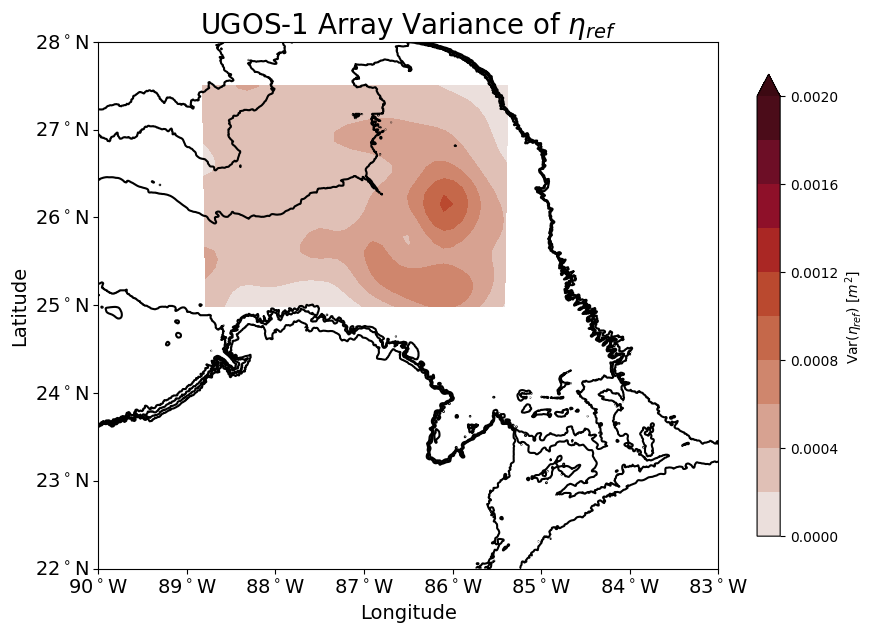

In [127]:
fig,ax = plt.subplots(figsize=(10,10))

#cb = ax.contourf(cpies_lon,cpies_lat,np.nanmean(cpies_twoYr_var,axis=0),cmap=cm.cm.amp,levels=np.linspace(0,0.002,11),extend='max')
cb = ax.contourf(oi_lon_ugos,oi_lat_ugos,np.nanvar(oi_eref_daily_ugos,axis=2),cmap=cm.cm.amp,levels=np.linspace(0,0.002,11),extend='max')
#cb = ax.contourf(oi_lon,oi_lat,np.nanvar(oi_eref_daily_dyn,axis=2),cmap=cm.cm.amp,levels=np.linspace(0,0.002,11),extend='max')
plt.colorbar(cb,shrink=0.6,label='Var($\eta_{ref}$) [$m^2$]')#,location='bottom')
#plt.colorbar(cb,shrink=0.6,label='$\eta_{ref}$ [$m$]')#,location='bottom')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
#plt.title('Composite of 2-Year Mean Variance of $\eta_{ref}$',fontsize=20)
plt.title('UGOS-1 Array Variance of $\eta_{ref}$',fontsize=20)
#plt.title('DynLoop Variance of $\eta_{ref}$',fontsize=20)

**Plot EKE**

In [ ]:
# Calculate Mean Eddy Kinetic Energy
# EKE = (u'^2 + v'^2) / 2

# Create velocity anomalies

# convert to cm/s
u_cm = u * 100
v_cm = v * 100

u_prime = u_cm - xr.DataArray.mean(u_cm,dim='MT',skipna=True)
v_prime = v_cm - xr.DataArray.mean(v_cm,dim='MT',skipna=True)

EKE = ((u_prime ** 2) + (v_prime ** 2)) / 2
EKE_mean = xr.DataArray.mean(EKE,dim='MT',skipna=True)

fig,ax = plt.subplots(figsize=(10,8))
cb = ax.contourf(lon,lat,EKE_mean,cmap='turbo',levels=np.linspace(0,150,16),extend='max')
plt.colorbar(cb,shrink=0.6,label='Mean EKE [$cm^2/s^2$]')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
ax.set_title('18-year Mean EKE at 2000m',fontsize=18)

In [ ]:
# For plotting vectors

# 18 year mean of eta ref
eref_18yr_mean = np.nanmean(eref.values,axis=0)

# Get every third (or whatever) point 
u_mean = xr.DataArray.mean(u_cm,dim='MT',skipna=True)
v_mean = xr.DataArray.mean(v_cm,dim='MT',skipna=True)

# Downsample every third point
ds_val = 4
u_downsampled = u_mean.isel(Latitude=slice(0, None, ds_val), Longitude=slice(0, None, ds_val))
v_downsampled = v_mean.isel(Latitude=slice(0, None, ds_val), Longitude=slice(0, None, ds_val))
lon_downsampled = lon.isel(Longitude=slice(0, None, ds_val))
lat_downsampled = lat.isel(Latitude=slice(0, None, ds_val))

LON,LAT = np.meshgrid(lon_downsampled,lat_downsampled)

fig,ax = plt.subplots(figsize=(10,8))
#cb = ax.contourf(lon,lat,EKE_mean,cmap='turbo',levels=np.linspace(0,150,16),extend='max')
cb = ax.contourf(lon,lat,eref_18yr_mean,cmap=cm.cm.balance,levels=np.linspace(-0.04,0.04,11),extend='both')
plt.quiver(LON,LAT,u_downsampled,v_downsampled,scale=100)
#plt.colorbar(cb,shrink=0.6,label='Mean EKE [$cm^2/s^2$]')
plt.colorbar(cb,shrink=0.6,label='Mean $\eta_{ref}$ [$m$]')
ax.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-',levels=[-3500,-3000,-2500,-2000])
ax.set_aspect(np.cos(ymid))
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.set_xlim(-90,-83)
ax.set_xticks(lon_xticks)
ax.set_xticklabels(lon_xticklbls)
ax.set_yticks(lat_yticks)
ax.set_yticklabels(lat_yticklbls)
ax.tick_params(axis='both',which='major',labelsize=14)
# ax.set_title('18-year Mean EKE at 2000m',fontsize=18)
ax.set_title('18-year Mean of $\eta_{ref}$',fontsize=18)

fig.savefig(f'./Figures/EtaRef_Mean_withVelocityVectors_{today}.svg',format='svg')

**Last Check**

Need to see what correlation function of Eta_ref turns out to be.

Can load in the locations of the CPIES and grab the points closest 

In [ ]:
# Load CPIES locations 

ds_sites = spio.loadmat('/home/justin_cooke_uri_edu/DeepCyclones/EF/ObsData/sites.mat')

sites_lon = ds_sites['cpies']['lon'][0]
sites_lat = ds_sites['cpies']['lat'][0]

# sanity check plot
fig,ax = plt.subplots(figsize=(20,20))
plt.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-')
for i in range(len(sites_lon)):
    plt.scatter(sites_lon[i],sites_lat[i],s=88)
ax.set_aspect(np.cos(ymid))

In [ ]:
hycom_sites = np.empty((len(sites_lon[0]),2))
hycom_idxes = np.empty((len(sites_lon[0]),2))
hycom_eref  = np.empty((len(sites_lon[0]),Nt))

for n in range(len(sites_lat[0])):
    site_lon = sites_lon[0][n]
    site_lat = sites_lat[0][n]

    idx_lon = np.where(lon.values >= site_lon)
    idx_lat = np.where(lat.values >= site_lat)

    hycom_sites[n,0] = lat.values[idx_lat[0][0]]
    hycom_sites[n,1] = lon.values[idx_lon[0][0]]

    hycom_idxes[n,0] = idx_lat[0][0]
    hycom_idxes[n,1] = idx_lon[0][0]

    hycom_eref[n,:] = full_eref_noCM[:,idx_lat[0][0],idx_lon[0][0]]


In [ ]:
# sanity check plot
fig,ax = plt.subplots(figsize=(10,10))
plt.contour(gulf_lon,gulf_lat,np.flipud(img),colors='black',linestyles='-')
for i in range(len(sites_lon)):
    plt.scatter(sites_lon[i],sites_lat[i],s=88)
for n in range(24):
    plt.scatter(hycom_sites[n,1],hycom_sites[n,0],s=88,facecolors='xkcd:sun yellow')
    ax.text(hycom_sites[n,1],hycom_sites[n,0]+0.1,f'Site {n+1}')
ax.set_aspect(np.cos(ymid))

In [ ]:
Nsites = hycom_sites.shape[0]
site_corr = np.empty((Nsites,Nsites-1))
site_dist = np.empty((Nsites,Nsites-1))

for n in range(Nsites):
    # get the first site that we will correlate all others against
    site_1 = (hycom_eref[n,:] - np.mean(hycom_eref[n,:]))
    lon_1 = hycom_sites[n,1]
    lat_1 = hycom_sites[n,0]
    counter = 0
        
    for m in range(Nsites):
        # make sure we are correlating against the same site
        if n != m:
            site_2 = (hycom_eref[m,:] - np.mean(hycom_eref[m,:]))
            lon_2 = hycom_sites[m,1]
            lat_2 = hycom_sites[m,0]
            
        else:
            continue

        site_dist[n,counter] = dist_calc(lat_1,lat_2,lon_1,lon_2)
        this_corr = np.corrcoef(site_1,site_2)
        site_corr[n,counter] = this_corr[0,1]
        counter += 1
        



In [ ]:
N = 0.1
r = np.linspace(50,350,100)
L1 = 70
L2 = 100
fit_check1 = (1-N) * np.exp(-1 * ((r/L1) ** 2))
fit_check2 = (1-N) * np.exp(-1 * ((r/L2) ** 2))

In [ ]:
for n in range(Nsites):
    plt.scatter(site_dist[n,:],site_corr[n,:],facecolor='xkcd:electric blue',marker='D')
plt.plot(r,fit_check1,label='N=0.1; L=70')
plt.plot(r,fit_check2,label='N=0.1; L=100')
plt.ylabel('Correlation',fontsize=16)
plt.xlabel('Distance [km]',fontsize=16)
plt.legend(loc='upper right')